# Exp3: Implement Linear Regression from Scratch using Gradient Descent

## **Setup & Imports**

In [9]:
# Simple Linear Regression on Customer dataset (from scratch, no sklearn)
# Methods: Analytical (Normal Equation) and Gradient Descent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Load Data**

In [10]:

import pandas as pd
df = pd.read_csv("customer.csv")
print(df.shape)
df.head()

(18, 6)


,Age,Income,Gender_Male,City_Delhi,City_Mumbai,Purchased
0,-2.078147,-3.870288,1.253566,1.414214,-0.797724,1
1,0.571681,-0.692186,-0.797724,1.414214,-0.797724,1
2,0.479554,0.395851,1.253566,-0.707107,1.253566,1
3,1.637140,0.788091,1.253566,1.414214,-0.797724,1
4,-0.770161,0.131660,-0.797724,-0.707107,-0.797724,1


**Select Strong (x, y) Pair**

In [11]:
# Pick two strongly correlated numeric columns automatically (excluding 'Purchased')
numeric_df = df.select_dtypes(include=[np.number])
numeric_cols = list(numeric_df.columns)
if "Purchased" in numeric_cols:
    numeric_cols.remove("Purchased")

# Correlation matrix
corr = df[numeric_cols].corr().abs()
np.fill_diagonal(corr.values, 0.0)

# Strongest correlated pair
idx = np.unravel_index(np.argmax(corr.values), corr.shape)
x_col = corr.columns[idx[0]]
y_col = corr.columns[idx[1]]

print(f"Selected feature (x): {x_col}")
print(f"Selected target (y): {y_col}")
print(f"Absolute correlation: {float(corr.values[idx]):.6f}")


Selected feature (x): Age
Selected target (y): Income
Absolute correlation: 0.656258


**Train-Test Split (No sklearn)**

In [12]:
# Prepare data
x = df[x_col].values.reshape(-1, 1)  # x_col is 'Age'
y = df[y_col].values.reshape(-1, 1)  # y_col is 'Income'

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

# Manual split (80/20)
rng = np.random.default_rng(42)
m = x.shape[0]
idxs = np.arange(m)
rng.shuffle(idxs)
split = int(0.8 * m)

train_idx, test_idx = idxs[:split], idxs[split:]

X_train, y_train = add_intercept(x[train_idx]), y[train_idx]
X_test, y_test   = add_intercept(x[test_idx]),  y[test_idx]

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 14 Test size: 4


**Normal Equation**

In [13]:
# θ = (X^T X)^(-1) X^T y
def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ (X.T @ y)

theta_ne = normal_equation(X_train, y_train)
print("Theta (Normal Equation):", theta_ne.ravel())


Theta (Normal Equation): [0.03352481 0.70028247]


**Gradient Descent**

In [14]:
def compute_cost(X, y, theta):
    m = X.shape[0]
    e = X @ theta - y
    return (e.T @ e).item() / (2*m)

def gradient_descent(X, y, alpha=0.05, iterations=1500):
    m, n = X.shape
    theta = np.zeros((n,1))
    history = []
    for it in range(iterations):
        grad = (X.T @ (X @ theta - y)) / m
        theta -= alpha * grad
        if (it+1) % 10 == 0 or it == 0:
            history.append(compute_cost(X, y, theta))
    return theta, history

theta_gd, history = gradient_descent(X_train, y_train, alpha=0.05, iterations=1500)
print("Theta (Gradient Descent):", theta_gd.ravel())


Theta (Gradient Descent): [0.03352481 0.70028247]


**Evaluation Metrics**

In [15]:
def mse(y_true, y_pred): return float(np.mean((y_true - y_pred)**2))
def mae(y_true, y_pred): return float(np.mean(np.abs(y_true - y_pred)))
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return float(1 - ss_res/ss_tot)

def evaluate(name, X, y, theta):
    yhat = X @ theta
    return name, mse(y, yhat), mae(y, yhat), r2(y, yhat)

results = []
results.append(evaluate("NE-Train", X_train, y_train, theta_ne))
results.append(evaluate("NE-Test",  X_test,  y_test,  theta_ne))
results.append(evaluate("GD-Train", X_train, y_train, theta_gd))
results.append(evaluate("GD-Test",  X_test,  y_test,  theta_gd))

print("\nPerformance (MSE, MAE, R2):")
for r in results:
    print(f"{r[0]:8s} -> MSE={r[1]:.6f}, MAE={r[2]:.6f}, R2={r[3]:.6f}")



Performance (MSE, MAE, R2):
NE-Train -> MSE=0.632584, MAE=0.559647, R2=0.479342
NE-Test  -> MSE=0.361702, MAE=0.412163, R2=-0.536680
GD-Train -> MSE=0.632584, MAE=0.559647, R2=0.479342
GD-Test  -> MSE=0.361702, MAE=0.412163, R2=-0.536680


**Visualizations**

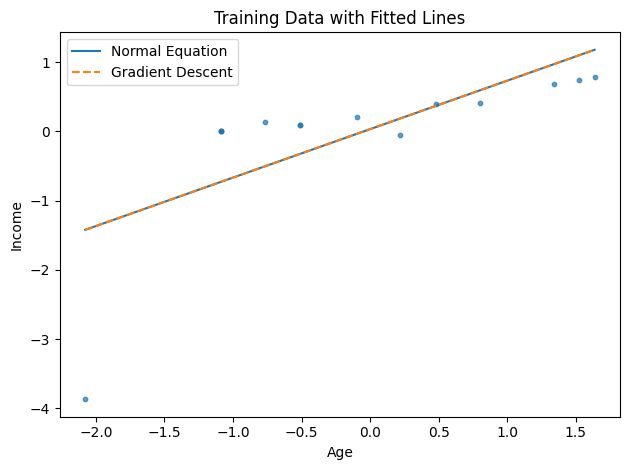

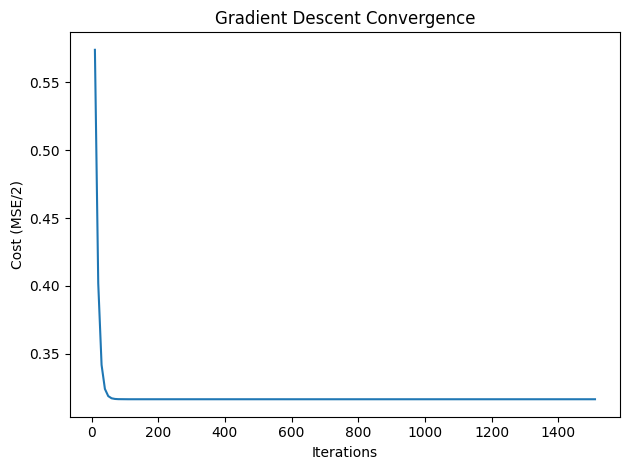

In [16]:
# 8.1 Scatter with fitted lines
plt.figure()
plt.scatter(X_train[:,1], y_train, s=10, alpha=0.7)
xs = np.linspace(X_train[:,1].min(), X_train[:,1].max(), 100).reshape(-1,1)
Xs = np.hstack([np.ones((xs.shape[0],1)), xs])
plt.plot(xs, Xs @ theta_ne, label="Normal Equation")
plt.plot(xs, Xs @ theta_gd, linestyle="--", label="Gradient Descent")
plt.xlabel(x_col); plt.ylabel(y_col)
plt.title("Training Data with Fitted Lines")
plt.legend(); plt.tight_layout()
plt.show()

# 8.2 GD Convergence
plt.figure()
plt.plot(np.arange(1, len(history)+1)*10, history)
plt.xlabel("Iterations"); plt.ylabel("Cost (MSE/2)")
plt.title("Gradient Descent Convergence")
plt.tight_layout()
plt.show()


## **Generate Synthetic Data (As Per Instructions)**

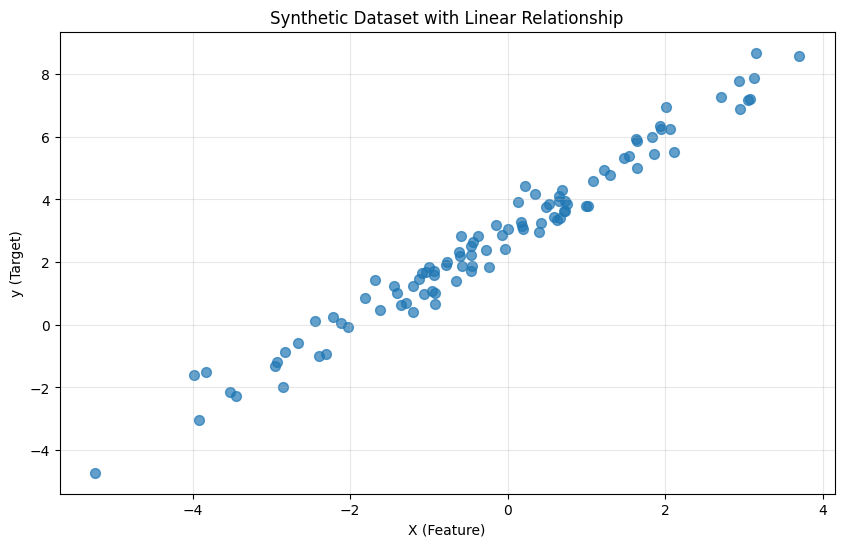

Dataset shape: (100, 1)
True parameters: θ₀ (intercept) = 3.0, θ₁ (slope) = 1.5
Linear relationship: y = 1.5x + 3.0 + noise


In [17]:
# Create synthetic dataset as per instructions
np.random.seed(42)
n_samples = 100

# Generate feature values (X) randomly
X_synthetic = np.random.randn(n_samples, 1) * 2

# Define true parameters (theta_true)
theta_true = np.array([[3.0], [1.5]])  # [intercept, slope]

# Add intercept column to X
X_with_intercept = np.hstack([np.ones((n_samples, 1)), X_synthetic])

# Generate target values (y) with noise
noise = np.random.randn(n_samples, 1) * 0.5
y_synthetic = X_with_intercept @ theta_true + noise

# Visualize the synthetic data
plt.figure(figsize=(10, 6))
plt.scatter(X_synthetic, y_synthetic, alpha=0.7, s=50)
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Dataset with Linear Relationship')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X_synthetic.shape}")
print(f"True parameters: θ₀ (intercept) = {theta_true[0,0]}, θ₁ (slope) = {theta_true[1,0]}")
print(f"Linear relationship: y = {theta_true[1,0]}x + {theta_true[0,0]} + noise")

## **Define Hypothesis Function**

In [18]:
def hypothesis(X, theta):
    """
    Calculate predicted values using the hypothesis function
    h(x) = X @ theta
    
    Parameters:
    X: Feature matrix with intercept column (m x 2)
    theta: Parameters [θ₀, θ₁] (2 x 1)
    
    Returns:
    Predicted values (m x 1)
    """
    return X @ theta

# Test the hypothesis function with synthetic data
print("Testing hypothesis function:")
test_theta = np.array([[2.0], [1.0]])  # Test parameters
predictions = hypothesis(X_with_intercept, test_theta)
print(f"Sample predictions shape: {predictions.shape}")
print(f"First 5 predictions: {predictions[:5].ravel()}")

Testing hypothesis function:
Sample predictions shape: (100, 1)
First 5 predictions: [2.99342831 1.7234714  3.29537708 5.04605971 1.53169325]


## **Implement Gradient Descent on Synthetic Data**

Training on Synthetic Data:
True parameters: θ₀ = 3.0, θ₁ = 1.5
Iteration 100, Cost: 0.778434
Iteration 200, Cost: 0.202989
Iteration 300, Cost: 0.123324
Iteration 400, Cost: 0.112244
Iteration 500, Cost: 0.110703
Iteration 600, Cost: 0.110489
Iteration 700, Cost: 0.110459
Iteration 800, Cost: 0.110455
Iteration 900, Cost: 0.110454
Iteration 1000, Cost: 0.110454

Learned parameters: θ₀ = 3.0036, θ₁ = 1.4642
Parameter differences: Δθ₀ = 0.0036, Δθ₁ = 0.0358


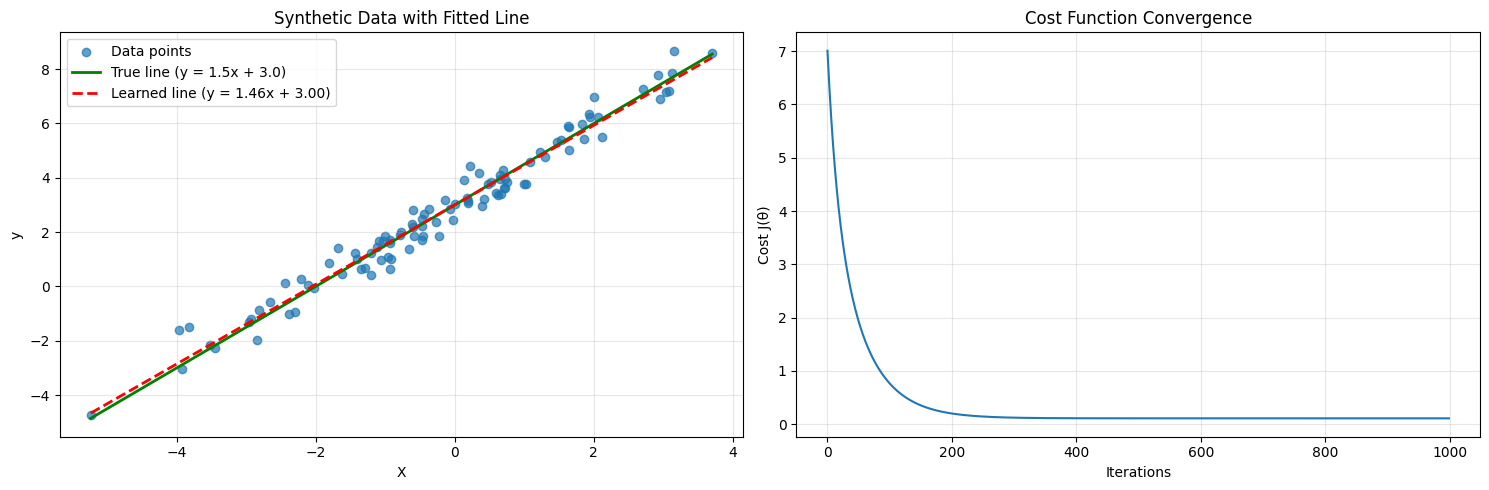

In [19]:
# Define cost function (Mean Squared Error)
def compute_cost_synthetic(X, y, theta):
    """
    Compute the cost function J(theta) = (1/2m) * sum((h(x) - y)^2)
    """
    m = X.shape[0]
    predictions = hypothesis(X, theta)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

# Define gradient descent for synthetic data
def gradient_descent_synthetic(X, y, alpha=0.01, iterations=1000):
    """
    Perform gradient descent to learn theta
    """
    m, n = X.shape
    theta = np.zeros((n, 1))  # Initialize parameters
    cost_history = []
    
    for i in range(iterations):
        # Calculate predictions
        predictions = hypothesis(X, theta)
        
        # Calculate gradients
        gradients = (1/m) * X.T @ (predictions - y)
        
        # Update parameters
        theta = theta - alpha * gradients
        
        # Store cost
        cost = compute_cost_synthetic(X, y, theta)
        cost_history.append(cost)
        
        # Print progress every 100 iterations
        if (i + 1) % 100 == 0:
            print(f"Iteration {i+1}, Cost: {cost:.6f}")
    
    return theta, cost_history

# Train on synthetic data
print("Training on Synthetic Data:")
print(f"True parameters: θ₀ = {theta_true[0,0]}, θ₁ = {theta_true[1,0]}")

# Run gradient descent
learned_theta, cost_history = gradient_descent_synthetic(X_with_intercept, y_synthetic, alpha=0.01, iterations=1000)

print(f"\nLearned parameters: θ₀ = {learned_theta[0,0]:.4f}, θ₁ = {learned_theta[1,0]:.4f}")
print(f"Parameter differences: Δθ₀ = {abs(learned_theta[0,0] - theta_true[0,0]):.4f}, Δθ₁ = {abs(learned_theta[1,0] - theta_true[1,0]):.4f}")

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Data with fitted line
ax1.scatter(X_synthetic, y_synthetic, alpha=0.7, label='Data points')
x_line = np.linspace(X_synthetic.min(), X_synthetic.max(), 100).reshape(-1, 1)
x_line_with_intercept = np.hstack([np.ones((x_line.shape[0], 1)), x_line])
y_true_line = x_line_with_intercept @ theta_true
y_pred_line = hypothesis(x_line_with_intercept, learned_theta)

ax1.plot(x_line, y_true_line, 'g-', label=f'True line (y = {theta_true[1,0]}x + {theta_true[0,0]})', linewidth=2)
ax1.plot(x_line, y_pred_line, 'r--', label=f'Learned line (y = {learned_theta[1,0]:.2f}x + {learned_theta[0,0]:.2f})', linewidth=2)
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Synthetic Data with Fitted Line')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cost function convergence
ax2.plot(cost_history)
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Cost J(θ)')
ax2.set_title('Cost Function Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()